In [1]:
from typing import List, TypedDict
from pydantic import BaseModel, Field
import time

from langchain_community.document_loaders import PyPDFLoader, DirectoryLoader
from langchain_community.vectorstores import FAISS
from langchain_groq import ChatGroq
from langchain_huggingface import HuggingFaceEmbeddings
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_core.documents import Document
from langchain_core.prompts import ChatPromptTemplate

from langgraph.graph import StateGraph, START, END
from dotenv import load_dotenv
import re

load_dotenv()

True

In [2]:
loader = DirectoryLoader(
    r"C:\Desktop\LangGraph\documents", 
    glob="./*.pdf", 
    loader_cls=PyPDFLoader,
    show_progress=True,
    use_multithreading=True
)

In [3]:
docs = loader.load()

100%|██████████| 3/3 [01:30<00:00, 30.02s/it]


In [4]:
chunks = RecursiveCharacterTextSplitter(chunk_size=900, chunk_overlap=150).split_documents(docs)

for d in chunks:
    d.page_content = d.page_content.encode("utf-8", "ignore").decode("utf-8", "ignore")

embeddings = HuggingFaceEmbeddings(model='sentence-transformers/all-MiniLM-L6-v2')
vector_store = FAISS.from_documents(chunks, embeddings)    

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [5]:
retriever = vector_store.as_retriever(search_type='similarity', search_kwargs={'k': 4})

In [6]:
llm = ChatGroq(model='openai/gpt-oss-120b')

In [7]:
UPPER_TH = 0.7
LOWER_TH = 0.3

In [8]:
class State(TypedDict):
    question: str
    docs: List[Document]

    good_docs: List[Document]
    verdict: str
    reason: str

    strips: List[str]
    kept_strips: List[str]
    refined_context: str

    answer: str


In [11]:
def retrieve_node(state: State):
    question = state['question']
    docs = retriever.invoke(question)
    return {'docs': docs}

In [17]:
class DocEvalScore(BaseModel):
    score: float
    reason: str


doc_eval_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict retrieval evaluator for RAG.\n"
            "You will be given ONE retrieved chunk and a question.\n"
            "Return a relevance score in [0.0, 1.0].\n"
            "- 1.0: chunk alone is sufficient to answer fully/mostly\n"
            "- 0.0: chunk is irrelevant\n"
            "Be conservative with high scores.\n"
            "Also return a short reason.\n"
            "Output JSON only.",
        ),
        ("human", "Question: {question}\n\nChunk:\n{chunk}"),
    ]
)

doc_eval_chain = doc_eval_prompt | llm.with_structured_output(DocEvalScore)

def each_doc_eval_node(state: State):

    q = state["question"]


    scores : List[float] = []
    reasons : List[str] = []
    good : List[Document] = []

    for d in state['docs']:
        out = doc_eval_chain.invoke({'question': q, 'chunk': d.page_content})
        scores.append(out.score)
        reasons.append(out.reason)

        if out.score > LOWER_TH:
            good.append(d)

     # 2) CORRECT if at least one doc > UPPER_TH
    if any(s > UPPER_TH for s in scores):
        return {
            "good_docs": good,
            "verdict": "CORRECT",
            "reason": f"At least one retrieved chunk scored > {UPPER_TH}.",
        }
    
    # 3) INCORRECT if all docs < LOWER_TH
    if len(scores) > 0 and all(s < LOWER_TH for s in scores):
        why = "No chunk was sufficient."
        return {
            "good_docs": [],
            "verdict": "INCORRECT",
            "reason": f"All retrieved chunks scored < {LOWER_TH}. {why}",
        }
    
    # 4) Anything in between => AMBIGUOUS
    why = "Mixed relevance signals."
    return {
        "good_docs": good,
        "verdict": "AMBIGUOUS",
        "reason": f"No chunk scored > {UPPER_TH}, but not all were < {LOWER_TH}. {why}",
    }

In [18]:
# -----------------------------
# Sentence-level DECOMPOSER
# -----------------------------
def decompose_to_sentences(text: str) -> List[str]:
    text = re.sub(r"\s+", " ", text).strip()
    sentences = re.split(r"(?<=[.!?])\s+", text)
    return [s.strip() for s in sentences if len(s.strip()) > 20]

# -----------------------------
# FILTER (LLM judge)
# -----------------------------
class KeepOrDrop(BaseModel):
    keep: bool

filter_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a strict relevance filter.\n"
            "Return keep=true only if the sentence directly helps answer the question.\n"
            "Use ONLY the sentence. Output JSON only.",
        ),
        ("human", "Question: {question}\n\nSentence:\n{sentence}"),
    ]
)

filter_chain = filter_prompt | llm.with_structured_output(KeepOrDrop)

# -----------------------------
# REFINING (Decompose -> Filter -> Recompose)
# -----------------------------
def refine(state: State) -> State:
    q = state["question"]

    # Combine retrieved docs into one context string
    # 5) In CORRECT case, eval node populates good_docs with docs having score > LOWER_TH
    context = "\n\n".join(d.page_content for d in state["good_docs"]).strip()

    # 1) DECOMPOSITION: context -> sentence strips
    strips = decompose_to_sentences(context)

    # 2) FILTER: keep only relevant strips
    kept: List[str] = []
    for s in strips:
        if filter_chain.invoke({"question": q, "sentence": s}).keep:
            kept.append(s)

    # 3) RECOMPOSE: glue kept strips back together (internal knowledge)
    refined_context = "\n".join(kept).strip()

    return {
        "strips": strips,
        "kept_strips": kept,
        "refined_context": refined_context,
    }



In [19]:
answer_prompt = ChatPromptTemplate.from_messages(
    [
        (
            "system",
            "You are a helpful ML tutor. Answer ONLY using the provided context.\n"
            "If the context is empty or insufficient, say: 'I don't know.'",
        ),
        ("human", "Question: {question}\n\nRefined context:\n{refined_context}"),
    ]
)

def generate(state: State) -> State:
    out = (answer_prompt | llm).invoke(
        {"question": state["question"], "refined_context": state["refined_context"]}
    )
    return {"answer": out.content}

In [20]:
def fail_node(state: State) -> State:
    return {"answer": f"FAIL: {state['reason']}"}

def ambiguous_node(state: State) -> State:
    return {"answer": f"Ambiguous: {state['reason']}"}

def route_after_eval(state: State) -> str:
    if state["verdict"] == "CORRECT":
        return "refine"
    elif state["verdict"] == "INCORRECT":
        return "web_search"
    else:
        return "ambiguous"

In [28]:
graph = StateGraph(State)

graph.add_node('retrieve', retrieve_node)
graph.add_node('eval_each_doc', each_doc_eval_node)
graph.add_node('ambiguous', ambiguous_node)
graph.add_node('refine', refine)
graph.add_node('fail', fail_node)
graph.add_node('generate', generate)


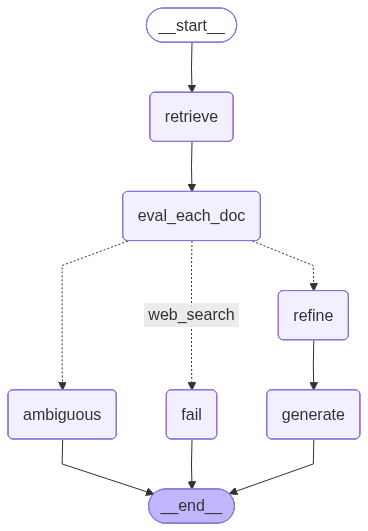

In [29]:
graph.add_edge(START, 'retrieve')
graph.add_edge('retrieve', 'eval_each_doc')

graph.add_conditional_edges('eval_each_doc', route_after_eval, {'refine': 'refine', 'web_search': 'fail', 'ambiguous': 'ambiguous'})

graph.add_edge('refine', 'generate')
graph.add_edge('generate', END)
graph.add_edge('fail', END)
graph.add_edge('ambiguous', END)

app = graph.compile()

app

In [31]:
initail_state = {"question": "what is Bias variance trade-off?"}
app.invoke(initail_state)

{'question': 'what is Bias variance trade-off?',
 'docs': [Document(id='2ef270cc-f9ad-4426-9f4c-8902a078814f', metadata={'producer': 'Acrobat Distiller 6.0 (Windows)', 'creator': 'Adobe Acrobat 6.0', 'creationdate': '2006-10-18T12:52:36+08:00', 'author': 'Christopher M. Bishop', 'moddate': '2008-02-08T16:41:33+01:00', 'title': 'Pattern Recognition and Machine Learning', 'source': 'C:\\Desktop\\LangGraph\\documents\\book1.pdf', 'total_pages': 758, 'page': 168, 'page_label': '149'}, page_content='and the bias and variance terms now refer to integrated quantities.\nOur goal is to minimize the expected loss, which we have decomposed into the\nsum of a (squared) bias, a variance, and a constant noise term. As we shall see, there\nis a trade-off between bias and variance, with very ﬂexible models having low bias\nand high variance, and relatively rigid models having high bias and low variance.\nThe model with the optimal predictive capability is the one that leads to the best\nbalance betwee